In [1]:
import pandas as pd
portXrefs = pd.read_csv("Port_Xrefs.csv")
portXrefs = portXrefs.set_index("Known_Port_Name", drop=True)['Best_Match'].to_dict()

HISTORICAL_FILE = "Port_Data_20251112.csv"



## Results

From Patty.  Her comments are in BOLD
<ul>
<li>     IMPORTS  = DOMESTIC InBound Loaded+ FOREIGN InBound <b>Loaded Domestic inbound loaded are not imports.  Just include foreign inbound loaded</b>
<li>      EXPORTS = DOMESTIC OutBoundLoaded + FOREIGN OutBound <b>Loaded Domestic outbound loaded are not exports.  Just include foreign outbound loaded</b>

<li>      EMPTY is being computed as Domestic inBound Empty + Domestic outBound Empty   
<b>correct</b>
</ul>

Dataset:
<ul>
<li> A Container_2022_Ranks_top25_byType_from_socrata.csv  -> Taken from the Port Web site from the TEU story
<li> B "WCSC 2022 Container traffic.xlsx" -> Provided by Patty, this is the source data from the update
<li> C PortDataExport.csv -> Provided by Patti as a possible source for 2022 updates
<li> D Port_data_20251112.csv  -> Current Source data from Socrata that we are attemping to update
</ul>

Results:
  Patty Update vs Patti 2nd Source
  TOTAL  Good: 21  Bad: 16
IMPORTS  Good: 37  Bad: 0
EXPORTS  Good: 37  Bad: 0
  EMPTY  Good: 37  Bad: 0

  The TOTAL is being computed as : 
  update: 
    df['TOTAL']= df['IMPORTS'] + df['EXPORTS'] + df['EMPTY']
    df['IMPORTS'] = df['DOMESTIC InBound Loaded']+ df['FOREIGN InBound Loaded'] 
    df['EXPORTS'] = df['DOMESTIC OutBound Loaded']+ df['FOREIGN OutBound Loaded'] 
    df['EMPTY'] = df['DOMESTIC InBound Empty'] + df['DOMESTIC OutBound Empty'] 
  2nd source: 
    Already Computed

  Meaning: 
    The update formulas I used are based mostly on this comparison.  Note that I believe for the TOTAL, the Good comparison is caused by the EMPTY values being 0, so they do not affect the Total.  I have confirmed, so the TOTAL agrees with Patties assessement, EMPTY should NOT be included.

    However, the IMPORTS and EXPORTS contradict her formulas
    IMPORTS  =  FOREIGN InBound
    EXPORTS  =  FOREIGN OutBound 

## Get ALL Data

 <table><tr>
 <td>File</td>
 <td>Period</td>
 <td>Source</td>
 <td>Port IDs</td>
 <td>Columns</td></tr>

 <tr>
    <td>Container_2022_Ranks_top25_byType_from_socrata.csv</td>
    <td>2022-2023</td>
    <td>Port Web Portal</td>
    <td>Generic - needs xrefs</td>
    <td>'Port_Name', 'Year', 'Domestic, Inbound, Loaded','Domestic, Outbound, Loaded', 'Foreign, Inbound, Loaded','Foreign, Outbound, Loaded'</td></tr>

<tr>
  <td>WCSC 2022 Container traffic.xlsx</td>
  <td>2022</td>
  <td>Patti - UPDATE FILE</td>
  <td>Generic - need xrefs</td>
  <td>'PORT NAME', 'STATE', 'DOMESTIC InBound Loaded',
       'DOMESTIC InBound Empty', 'DOMESTIC OutBound Loaded',
       'DOMESTIC OutBound Empty', 'DOMESTIC Total Domestic',
       'FOREIGN InBound Loaded', 'FOREIGN OutBound Loaded',
       'FOREIGN Total Foreign Loaded', 'Grand Total Loaded', 'IMPORTS',
       'EXPORTS', 'EMPTY', 'TOTAL'</td>
</tr>
<tr>
  <td>PortDataExport.csv</td>
  <td>2018-2022</td>
  <td>Patti - secondary source</td>
  <td>Standard</td>
  <td>'Cargo Type', 'Port ID', 'Port_Name', 'Region', 'Reporting Year',
       'State', 'Trade Type', 'Units', 'Port Ranking', 'Percent Change','Volume'
  </td>  
</tr>

</tr>
<tr>
  <td>Port_Data_20251112.csv</td>
  <td>2016-2021</td>
  <td>Port Data Catalog -> source we are updating</td>
  <td>Standard</td>
  <td>'Cargo Type', 'Port ID', 'Port_Name', 'Region', 'Reporting Year',
       'State', 'Trade Type', 'Units', 'Port Ranking', 'Percent Change','Volume'
  </td>  
</tr>
</table>


### From Port Web Site - Socrata

In [37]:
a= pd.read_csv('Container_2022_Ranks_top25_byType_from_socrata.csv', 
                 sep='\t', 
                 encoding='utf-16',engine='python')
a.columns = a.columns.str.replace(".1","",regex=False).str.strip()
container_socr = a.T[1:]
container_socr.columns = a.T.iloc[0]
container_socr.reset_index(inplace=True)
container_socr.rename(columns={'Type':'Year',"index":"Port_Name"}, inplace=True    )
container_socr['Year'] = container_socr['Year'].str.strip().astype(int)
container_socr['Domestic, Inbound, Loaded'] = container_socr['Domestic, Inbound, Loaded'].str.replace(",","").astype(int)
container_socr['Domestic, Outbound, Loaded'] = container_socr['Domestic, Outbound, Loaded'].str.replace(",","").astype(int)
container_socr['Foreign, Inbound, Loaded'] = container_socr['Foreign, Inbound, Loaded'].str.replace(",","").astype(int)
container_socr['Foreign, Outbound, Loaded'] = container_socr['Foreign, Outbound, Loaded'].str.replace(",","").astype(int)


### From Patty -> Update

In [122]:
REPORTING_YEAR = 2022


container_update = pd.read_excel("WCSC 2022 Container traffic.xlsx", header=[0, 1, 2])
df = container_update.copy()
a=df.columns.tolist()
colsNew = []
for b in a:
    final=""

    for c in b:
        if "Unnamed:" in c:
            continue
        else:
            final += c.strip() + " "
    colsNew.append(final.strip())
    
df.columns = colsNew

# df['IMPORTS'] = df['DOMESTIC InBound Loaded']+ df['FOREIGN InBound Loaded'] 
# df['EXPORTS'] = df['DOMESTIC OutBound Loaded']+ df['FOREIGN OutBound Loaded'] 
df['IMPORTS'] = df['FOREIGN InBound Loaded'] 
df['EXPORTS'] = df['FOREIGN OutBound Loaded'] 

df['EMPTY'] = df['DOMESTIC InBound Empty'] + df['DOMESTIC OutBound Empty'] 
#df['TOTAL'] = df['Grand Total Loaded']
#df['TOTAL'] = df['IMPORTS'] + df['EXPORTS'] + df['EMPTY']
df['TOTAL'] = df['IMPORTS'] + df['EXPORTS'] 
container_update_all = df.copy()
df_contain = df[[ 'PORT NAME', 'STATE','TOTAL', 'IMPORTS','EXPORTS', 'EMPTY']].copy()
if REPORTING_YEAR == 2023:
    df_contain['PORT CODE'] = df['PORT CODE'].astype(int)     
else:
    df_contain['PORT CODE'] = None

    
df_contain['REPORTING YEAR'] = REPORTING_YEAR 
container_update = df_contain.copy()                              


### Historical Port Data Catalog

In [4]:
df_hist = pd.read_csv(HISTORICAL_FILE)
df_hist['Port ID'] = df_hist['Port ID'].str.replace(",","").astype(int)

df_hist['Percent Change'] = df_hist['Percent Change'].str.replace(",","").astype(float) 
df_hist['Percent Change'] = df_hist['Percent Change'].round(1) 
df_hist['Volume'] = df_hist['Volume'].str.replace(",","").astype(float).round(1) 
ports_hist = df_hist[['Port_Name','Port ID','State', 'Region']].drop_duplicates()
ports_hist.dropna(inplace=True)

container_hist = df_hist[(df_hist['Cargo Type'] == 'CONTAINER') & (df_hist['Reporting Year'] == REPORTING_YEAR)].copy()

### Port Data Exports Extra FIle from Patti

In [5]:
pde = pd.read_csv("PortDataExport.csv", encoding='utf-8')
container_pde = pde[(pde['Cargo Type'] == 'CONTAINER') & (pde['Reporting Year'] == REPORTING_YEAR)].copy()                


In [43]:
pde['Reporting Year'].value_counts()

Reporting Year
2022    1408
2021     622
2020     567
2019     529
2018     519
Name: count, dtype: int64

## Check Imports-Emports-Empty

### Update vs Patty 2nd Source

In [6]:
nchk=0
ngood=0
nbad=0
totl=0
stats={}
for pid in ports_hist['Port_Name'].sort_values().unique().tolist():
    if pid in portXrefs:
        xport = portXrefs[pid]
    else:
        print("Missed ",pid)
        continue
    tmp = container_update[container_update['PORT NAME'] == xport]    
    if tmp.empty:
        print("No update for ",pid)
        continue
    totl+=1
    
    for tt in ['TOTAL', 'IMPORTS', 'EXPORTS', 'EMPTY']:
        dval = round(tmp.loc[:, tt].values[0])
        nchk+=1
        pval=container_pde.loc[(container_pde['Port_Name'] == pid) & (container_pde['Trade Type'] == tt), 'Volume'] 
        if not pval.empty:
             pval =  pval.values[0].replace(",","")
             pval = round(float(pval))
             diff = abs(pval-dval)
             if tt not in stats:
                 stats[tt] = {}
                 stats[tt]['good']=0
                 stats[tt]['bad']=0
             if diff > 1:
                print(f"{port} {tt} PDE: {pval} vs WCSC: {dval} Diff: {diff}")
                stats[tt]['bad']+=1
                nbad+=1
             else:
                stats[tt]['good']+=1
                ngood+=1
print(f"Check: {nchk}  Good: {ngood} Bad: {nbad}")
print(f"Total Stns {ports_hist.shape[0]}  Total checks {totl}")

for tt,dct in stats.items():
    print(f"{tt}  Good: {dct['good']}  Bad: {dct['bad']}")

NameError: name 'port' is not defined

In [8]:
container_update 

,PORT NAME,STATE,TOTAL,IMPORTS,EXPORTS,EMPTY,PORT CODE,REPORTING YEAR
0,"Port Authority of New York and New Jersey, NY ...","NY,NJ",6660317.08,5380190.91,1280126.17,9415.5,None,2021
1,"Port of Los Angeles, CA",CA,6424341.44,5231585.42,1192756.02,0.0,None,2021
2,"Port of Long Beach, CA",CA,6091977.24,4715416.43,1376560.81,21590.2,None,2021
3,"Port of Savannah, GA",GA,4329915.37,3012685.25,1317230.12,0.0,None,2021
4,"Port of Houston Authority of Harris County, TX",TX,3252556.56,2035577.64,1216978.92,567.0,None,2021
...,...,...,...,...,...,...,...,...
105,"Port Milwaukee, WI",WI,6.00,6.00,0.00,0.0,None,2021
106,"DeTour, MI",MI,5.75,5.75,0.00,0.0,None,2021
107,"Port of Providence, RI",RI,3.50,3.50,0.00,0.0,None,2021
108,"Sault Ste Marie, MI",MI,1.75,1.75,0.00,0.0,None,2021


In [9]:
df_hist

,Cargo Type,Port ID,Port_Name,Region,Reporting Year,State,Trade Type,Units,Port Ranking,Percent Change,Volume
0,CONTAINER,4820,"Alaska, AK Port of",Pacific Coast,2016,Alaska,EMPTY,Container TEUs,18.0,42.9,58059.2
1,CONTAINER,4820,"Alaska, AK Port of",Pacific Coast,2016,Alaska,EXPORTS,Container TEUs,18.0,-5.9,71170.0
2,CONTAINER,4820,"Alaska, AK Port of",Pacific Coast,2016,Alaska,IMPORTS,Container TEUs,18.0,-16.0,205662.3
3,CONTAINER,4820,"Alaska, AK Port of",Pacific Coast,2016,Alaska,TOTAL,Container TEUs,18.0,-7.3,334891.4
4,DRY BULK,4820,"Alaska, AK Port of",Pacific Coast,2016,Alaska,DOMESTIC,Short Tons,161.0,-10.2,96901.0
...,...,...,...,...,...,...,...,...,...,...,...
5184,VESSEL CALLS,7713,Illinois Waterway Ports and Terminals Port Sta...,NaN,2020,Illinois,Container,Vessel Calls,NaN,0.0,NaN
5185,VESSEL CALLS,7713,Illinois Waterway Ports and Terminals Port Sta...,NaN,2020,Illinois,Dry Bulk,Vessel Calls,NaN,0.0,NaN
5186,VESSEL CALLS,7713,Illinois Waterway Ports and Terminals Port Sta...,NaN,2020,Illinois,Dry Bulk Barge,Vessel Calls,NaN,0.0,7353.5
5187,VESSEL CALLS,7713,Illinois Waterway Ports and Terminals Port Sta...,NaN,2020,Illinois,Other Freight,Vessel Calls,NaN,0.0,NaN


In [10]:
container_update

,PORT NAME,STATE,TOTAL,IMPORTS,EXPORTS,EMPTY,PORT CODE,REPORTING YEAR
0,"Port Authority of New York and New Jersey, NY ...","NY,NJ",6660317.08,5380190.91,1280126.17,9415.5,None,2021
1,"Port of Los Angeles, CA",CA,6424341.44,5231585.42,1192756.02,0.0,None,2021
2,"Port of Long Beach, CA",CA,6091977.24,4715416.43,1376560.81,21590.2,None,2021
3,"Port of Savannah, GA",GA,4329915.37,3012685.25,1317230.12,0.0,None,2021
4,"Port of Houston Authority of Harris County, TX",TX,3252556.56,2035577.64,1216978.92,567.0,None,2021
...,...,...,...,...,...,...,...,...
105,"Port Milwaukee, WI",WI,6.00,6.00,0.00,0.0,None,2021
106,"DeTour, MI",MI,5.75,5.75,0.00,0.0,None,2021
107,"Port of Providence, RI",RI,3.50,3.50,0.00,0.0,None,2021
108,"Sault Ste Marie, MI",MI,1.75,1.75,0.00,0.0,None,2021


### Port Data Catalog vs PDE

In [11]:
container_pde

,Cargo Type,Port ID,Port_Name,Region,Reporting Year,State,Trade Type,Units,Port Ranking,Percent Change,Volume
1132,CONTAINER,398,"New York, NY & NJ",Atlantic Coast,2021,New Jersey and New York,EMPTY,Container TEUs,3.0,0,"2,732"
1133,CONTAINER,398,"New York, NY & NJ",Atlantic Coast,2021,New Jersey and New York,EXPORTS,Container TEUs,3.0,6.445858346,"1,334,170.78"
1134,CONTAINER,398,"New York, NY & NJ",Atlantic Coast,2021,New Jersey and New York,IMPORTS,Container TEUs,3.0,18.735963300,"4,969,906.78"
1135,CONTAINER,398,"New York, NY & NJ",Atlantic Coast,2021,New Jersey and New York,TOTAL,Container TEUs,3.0,15.903824925,"6,304,077.56"
1144,CONTAINER,550,"South Jersey Port, NJ",Atlantic Coast,2021,New Jersey,EMPTY,Container TEUs,24.0,7.253293911,"24,449.3"
...,...,...,...,...,...,...,...,...,...,...,...
1723,CONTAINER,4820,"Alaska, AK Port of",Pacific Coast,2021,Alaska,TOTAL,Container TEUs,19.0,8.780637487,"415,661.15"
1740,CONTAINER,5700,"Virginia, VA, Port of",Atlantic Coast,2021,Virginia,EMPTY,Container TEUs,5.0,0,0
1741,CONTAINER,5700,"Virginia, VA, Port of",Atlantic Coast,2021,Virginia,EXPORTS,Container TEUs,5.0,19.254530383,"1,016,780.13"
1742,CONTAINER,5700,"Virginia, VA, Port of",Atlantic Coast,2021,Virginia,IMPORTS,Container TEUs,5.0,32.850214610,"1,753,184.56"


In [12]:
container_hist 

,Cargo Type,Port ID,Port_Name,Region,Reporting Year,State,Trade Type,Units,Port Ranking,Percent Change,Volume
70,CONTAINER,4820,"Alaska, AK Port of",Pacific Coast,2021,Alaska,EMPTY,Container TEUs,18.0,6.2,130415.2
71,CONTAINER,4820,"Alaska, AK Port of",Pacific Coast,2021,Alaska,EXPORTS,Container TEUs,18.0,9.8,101102.6
72,CONTAINER,4820,"Alaska, AK Port of",Pacific Coast,2021,Alaska,IMPORTS,Container TEUs,18.0,8.5,314558.6
73,CONTAINER,4820,"Alaska, AK Port of",Pacific Coast,2021,Alaska,TOTAL,Container TEUs,18.0,8.2,546076.3
171,CONTAINER,700,"Baltimore, MD",Atlantic Coast,2021,Maryland,EMPTY,Container TEUs,15.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
4241,CONTAINER,555,"Wilmington, DE",Atlantic Coast,2021,Delaware,TOTAL,Container TEUs,22.0,-7.1,199336.6
4339,CONTAINER,766,"Wilmington, NC",Atlantic Coast,2021,North Carolina,EMPTY,Container TEUs,21.0,0.0,0.0
4340,CONTAINER,766,"Wilmington, NC",Atlantic Coast,2021,North Carolina,EXPORTS,Container TEUs,21.0,23.4,129420.9
4341,CONTAINER,766,"Wilmington, NC",Atlantic Coast,2021,North Carolina,IMPORTS,Container TEUs,21.0,-3.8,121728.0


In [36]:
nchk=0
ngood=0
nbad=0
totl=0
stats={}
for pid in ports_hist['Port_Name'].sort_values().unique().tolist():
    if pid in portXrefs:
        xport = portXrefs[pid]
    else:
        print("Missed ",pid)
        continue
    tmp = container_hist[container_hist['Port_Name'] == pid]    
    if tmp.empty:
        print("No update for ",pid)
        continue
    totl+=1
    
    for _,row in tmp.iterrows():
        tt = row['Trade Type']
        dval = round(row['Volume'])
        nchk+=1
        pval=container_pde.loc[(container_pde['Port_Name'] == pid) & (container_pde['Trade Type'] == tt), 'Volume'] 
        if not pval.empty:
             pval =  pval.values[0].replace(",","")
             pval = round(float(pval))
             diff = abs(pval-dval)
             if tt not in stats:
                 stats[tt] = {}
                 stats[tt]['good']=0
                 stats[tt]['bad']=0
             if diff > 1:
                print(f"{pid} {tt} PDE: {pval} vs WCSC: {dval} Diff: {diff}")
                stats[tt]['bad']+=1
                nbad+=1
             else:
                stats[tt]['good']+=1
                ngood+=1
                print(f"Good {pid} -> {xport} {tt} PDE: {pval} vs WCSC: {dval} Diff: {diff}")
 
                a=container_update_all.loc[container_update_all['PORT NAME'] == pid]
                if not a.empty:
                    print(f"{tt} {dval}")
                    for col in ['DOMESTIC InBound Loaded','FOREIGN InBound Loaded','IMPORTS',
                                'DOMESTIC OutBound Loaded','FOREIGN OutBound Loaded','EXPORTS',
                                'DOMESTIC OutBound Empty', 'DOMESTIC InBound Empty','DOMESTIC Total Domestic']:
                        
                        print(f"{col:25s}  {round(a[col].values[0])}")
                    print("-------------------------")


        else:
            print(f"No PDE value for {pid} {tt}")   
print(f"Check: {nchk}  Good: {ngood} Bad: {nbad}")
print(f"Total Stns {ports_hist.shape[0]}  Total checks {totl}")

for tt,dct in stats.items():
    print(f"{tt}  Good: {dct['good']}  Bad: {dct['bad']}")

Good Alaska, AK Port of -> Port of Alaska, AK EMPTY PDE: 130415 vs WCSC: 130415 Diff: 0
Good Alaska, AK Port of -> Port of Alaska, AK EXPORTS PDE: 101103 vs WCSC: 101103 Diff: 0
Good Alaska, AK Port of -> Port of Alaska, AK IMPORTS PDE: 314559 vs WCSC: 314559 Diff: 0
Alaska, AK Port of TOTAL PDE: 415661 vs WCSC: 546076 Diff: 130415
Good Baltimore, MD -> Baltimore, MD EMPTY PDE: 0 vs WCSC: 0 Diff: 0
EMPTY 0
DOMESTIC InBound Loaded    35993
FOREIGN InBound Loaded     521729
IMPORTS                    557722
DOMESTIC OutBound Loaded   23096
FOREIGN OutBound Loaded    210044
EXPORTS                    233140
DOMESTIC OutBound Empty    6310
DOMESTIC InBound Empty     774
DOMESTIC Total Domestic    66173
-------------------------
Good Baltimore, MD -> Baltimore, MD EXPORTS PDE: 249300 vs WCSC: 249300 Diff: 0
EXPORTS 249300
DOMESTIC InBound Loaded    35993
FOREIGN InBound Loaded     521729
IMPORTS                    557722
DOMESTIC OutBound Loaded   23096
FOREIGN OutBound Loaded    210044
EXP

In [18]:
container_pde.loc[container_pde['Port_Name'] == 'Alaska, AK Port of']

,Cargo Type,Port ID,Port_Name,Region,Reporting Year,State,Trade Type,Units,Port Ranking,Percent Change,Volume
1720,CONTAINER,4820,"Alaska, AK Port of",Pacific Coast,2021,Alaska,EMPTY,Container TEUs,19.0,6.202991905,"130,415.15"
1721,CONTAINER,4820,"Alaska, AK Port of",Pacific Coast,2021,Alaska,EXPORTS,Container TEUs,19.0,9.796983973,"101,102.6"
1722,CONTAINER,4820,"Alaska, AK Port of",Pacific Coast,2021,Alaska,IMPORTS,Container TEUs,19.0,8.457956315,"314,558.55"
1723,CONTAINER,4820,"Alaska, AK Port of",Pacific Coast,2021,Alaska,TOTAL,Container TEUs,19.0,8.780637487,"415,661.15"


In [29]:
a=container_update_all.loc[container_update_all['PORT NAME'] == 'Port of Alaska, AK']


In [26]:
container_update_all.columns

Index(['PORT NAME', 'STATE', 'DOMESTIC InBound Loaded',
       'DOMESTIC InBound Empty', 'DOMESTIC OutBound Loaded',
       'DOMESTIC OutBound Empty', 'DOMESTIC Total Domestic',
       'FOREIGN InBound Loaded', 'FOREIGN OutBound Loaded',
       'FOREIGN Total Foreign Loaded', 'Grand Total Loaded', 'IMPORTS',
       'EXPORTS', 'EMPTY', 'TOTAL'],
      dtype='object')

In [ ]:
for pid in ports_hist['Port_Name'].unique()
for col in ['DOMESTIC InBound Loaded','FOREIGN InBound Loaded','IMPORTS',
            'DOMESTIC OutBound Loaded','FOREIGN OutBound Loaded','EXPORTS',
            'DOMESTIC OutBound Empty', 'DOMESTIC InBound Empty','DOMESTIC Total Domestic']:
    print(f"{col:25s}  {round(a[col].values[0])}")

DOMESTIC InBound Loaded    323565
FOREIGN InBound Loaded     49
IMPORTS                    323614
DOMESTIC OutBound Loaded   96139
FOREIGN OutBound Loaded    0
EXPORTS                    96139
DOMESTIC OutBound Empty    135577
DOMESTIC InBound Empty     1442
DOMESTIC Total Domestic    556724


In [45]:
ports_hist

,Port_Name,Port ID,State,Region
0,"Alaska, AK Port of",4820,Alaska,Pacific Coast
101,"Baltimore, MD",700,Maryland,Atlantic Coast
202,"Beaumont, TX",2393,Texas,Gulf Coast & Mississippi River
281,"Boston, MA",149,Massachusetts,Atlantic Coast
382,"Cincinnati-Northern KY, Ports of",2338,Kentucky and Ohio,Gulf Coast & Mississippi River
432,"Cleveland-Cuyahoga Port, OH",3217,Ohio,Great Lakes
500,"Corpus Christi, TX",2436,Texas,Gulf Coast & Mississippi River
581,"Duluth-Superior, MN and WI",3924,Minnesota and Wisconsin,Great Lakes
635,"Tacoma, WA",4719,Washington,Pacific Coast
663,"Greater Baton Rouge, LA Port of",2252,Louisiana,Gulf Coast & Mississippi River


In [ ]:
container_pde
container_hist
container_socr
container_update

In [46]:
for _,row in ports_hist.iterrows():
    print(row)

Port_Name    Alaska, AK Port of
Port ID                    4820
State                    Alaska
Region            Pacific Coast
Name: 0, dtype: object
Port_Name     Baltimore, MD
Port ID                 700
State              Maryland
Region       Atlantic Coast
Name: 101, dtype: object
Port_Name                      Beaumont, TX
Port ID                                2393
State                                 Texas
Region       Gulf Coast & Mississippi River
Name: 202, dtype: object
Port_Name        Boston, MA
Port ID                 149
State         Massachusetts
Region       Atlantic Coast
Name: 281, dtype: object
Port_Name    Cincinnati-Northern KY, Ports of
Port ID                                  2338
State                       Kentucky and Ohio
Region         Gulf Coast & Mississippi River
Name: 382, dtype: object
Port_Name    Cleveland-Cuyahoga Port, OH
Port ID                             3217
State                               Ohio
Region                       Great Lakes
N

In [ ]:
for pid,xrf in sorted(portXrefs.items()):
    

In [49]:
container_pde.columns
# container_hist
# container_socr
# container_update

Index(['Cargo Type', 'Port ID', 'Port_Name', 'Region', 'Reporting Year',
       'State', 'Trade Type', 'Units', 'Port Ranking', 'Percent Change',
       'Volume'],
      dtype='object')

In [ ]:
names_pde = container_pde['Port_Name'].str.strip().unique().tolist()
pids_pde = container_pde['Port ID'].unique().tolist()
names_socr = container_socr['Port_Name'].str.strip().unique().tolist()

names_update = container_update['PORT NAME'].str.strip().unique().tolist()


KeyError: 'Port ID'

In [88]:
container_socr.columns

Index(['Port_Name', 'Year', 'Domestic, Inbound, Loaded',
       'Domestic, Outbound, Loaded', 'Foreign, Inbound, Loaded',
       'Foreign, Outbound, Loaded'],
      dtype='object', name='Unnamed: 0')

In [93]:
hist_names={}
hist_names['pde'] = {'pid':{'hit':0,'miss':0},'xrf':{'hit':0,'miss':0}}
hist_names['socr'] = {'pid':{'hit':0,'miss':0},'xrf':{'hit':0,'miss':0}}
hist_names['updt'] = {'pid':{'hit':0,'miss':0},'xrf':{'hit':0,'miss':0}}


for name,xrf in portXrefs.items():
    both=False
    if name in names_pde:
        hist_names['pde']['pid']['hit']+=1
    else:
        hist_names['pde']['pid']['miss']+=1
        print(f"P :{name}:")
        both=True

    if name in names_socr:
        hist_names['socr']['pid']['hit']+=1
    else:
        hist_names['socr']['pid']['miss']+=1

    if name in names_update:
        hist_names['updt']['pid']['hit']+=1
    else:
        hist_names['updt']['pid']['miss']+=1


    if xrf in names_pde:
        hist_names['pde']['xrf']['hit']+=1
    else:
        hist_names['pde']['xrf']['miss']+=1
        if both:
           print(f"X :{name}:")


    if xrf in names_socr:
        hist_names['socr']['xrf']['hit']+=1
    else:
        hist_names['socr']['xrf']['miss']+=1

    if xrf in names_update:
        hist_names['updt']['xrf']['hit']+=1
    else:
        hist_names['updt']['xrf']['miss']+=1
        print(f"X :{xrf}:")

P :Boston, MA:
X :Boston, MA:
P :Cincinnati-Northern KY, Ports of:
X :Cincinnati-Northern KY, Ports of:
X :nan:
P :Greater Baton Rouge, LA Port of:
X :Greater Baton Rouge, LA Port of:
P :Huntington-Tristate, KY, OH, WV:
X :Huntington-Tristate, KY, OH, WV:
X :nan:
P :Kalama, WA Port of:
X :Kalama, WA Port of:
X :nan:
P :Mid-America Port Commission:
X :Mid-America Port Commission:
X :nan:
P :New Bourbon Port, MO:
X :New Bourbon Port, MO:
X :nan:
P :Northern Indiana, IN:
X :Northern Indiana, IN:
X :nan:
P :Pittsburgh, PA Port of:
X :Pittsburgh, PA Port of:
X :nan:
P :Port of Charleston, SC:
X :Port of Charleston, SC:
P :Port of Palm Beach District, FL:
X :Port of Palm Beach District, FL:
P :Southern Indiana Maritime District, IN:
X :Southern Indiana Maritime District, IN:
X :nan:
P :St. Louis, MO and IL:
X :St. Louis, MO and IL:
X :nan:
P :Toledo-Lucas County Port, OH:
X :Toledo-Lucas County Port, OH:
X :nan:
P :Two Harbors, MN:
X :Two Harbors, MN:
X :nan:
P :Valdez, AK:
X :Valdez, AK:


In [94]:
hist_names

{'pde': {'pid': {'hit': 36, 'miss': 16}, 'xrf': {'hit': 18, 'miss': 34}},
 'socr': {'pid': {'hit': 18, 'miss': 34}, 'xrf': {'hit': 17, 'miss': 35}},
 'updt': {'pid': {'hit': 21, 'miss': 31}, 'xrf': {'hit': 41, 'miss': 11}}}

In [77]:
for nn in sorted(names_update):
    print(nn)

Baltimore, MD
Boston, MA
Honolulu, O'ahu, HI
Houston Port Authority, TX
Jacksonville, FL
Mobile, AL
New Orleans, LA
New York, NY & NJ
Oxnard Harbor District, CA
Philadelphia Regional Port, PA
Port Everglades, FL
Port of Alaska, AK
Port of Charleston, SC
Port of Gulfport, MS
Port of Long Beach, CA
Port of Los Angeles, CA
Port of Oakland, CA
Port of Savannah, GA
PortMiami, FL
San Juan, PR
Seattle, WA
South Jersey Port Corp, NJ
Tacoma, WA
Virginia, VA, Port of
Wilmington, DE
Wilmington, NC


In [95]:
container_pde 

,Cargo Type,Port ID,Port_Name,Region,Reporting Year,State,Trade Type,Units,Port Ranking,Percent Change,Volume
1132,CONTAINER,398,"New York, NY & NJ",Atlantic Coast,2021,New Jersey and New York,EMPTY,Container TEUs,3.0,0,"2,732"
1133,CONTAINER,398,"New York, NY & NJ",Atlantic Coast,2021,New Jersey and New York,EXPORTS,Container TEUs,3.0,6.445858346,"1,334,170.78"
1134,CONTAINER,398,"New York, NY & NJ",Atlantic Coast,2021,New Jersey and New York,IMPORTS,Container TEUs,3.0,18.735963300,"4,969,906.78"
1135,CONTAINER,398,"New York, NY & NJ",Atlantic Coast,2021,New Jersey and New York,TOTAL,Container TEUs,3.0,15.903824925,"6,304,077.56"
1144,CONTAINER,550,"South Jersey Port, NJ",Atlantic Coast,2021,New Jersey,EMPTY,Container TEUs,24.0,7.253293911,"24,449.3"
...,...,...,...,...,...,...,...,...,...,...,...
1723,CONTAINER,4820,"Alaska, AK Port of",Pacific Coast,2021,Alaska,TOTAL,Container TEUs,19.0,8.780637487,"415,661.15"
1740,CONTAINER,5700,"Virginia, VA, Port of",Atlantic Coast,2021,Virginia,EMPTY,Container TEUs,5.0,0,0
1741,CONTAINER,5700,"Virginia, VA, Port of",Atlantic Coast,2021,Virginia,EXPORTS,Container TEUs,5.0,19.254530383,"1,016,780.13"
1742,CONTAINER,5700,"Virginia, VA, Port of",Atlantic Coast,2021,Virginia,IMPORTS,Container TEUs,5.0,32.850214610,"1,753,184.56"


In [67]:
name

'Wilmington, NC'

In [68]:
for name,xrf in portXrefs.items():
    print(name,xrf)

Alaska, AK Port of Port of Alaska, AK
Baltimore, MD Baltimore, MD
Beaumont, TX Beaumont, TX
Boston, MA Port of Boston, MA
Cincinnati-Northern KY, Ports of nan
Cleveland-Cuyahoga Port, OH Cleveland-Cuyahoga County, OH
Corpus Christi, TX Corpus Christi, TX
Duluth-Superior, MN and WI Duluth-Superior, MN and WI
Tacoma, WA Tacoma, WA
Greater Baton Rouge, LA Port of Port of Greater Baton Rouge, LA
Gulfport, MS Port of Gulfport, MS
Honolulu, O'ahu, HI Honolulu, O'ahu, HI
Houston Port Authority, TX Port of Houston Authority of Harris County, TX
Huntington-Tristate, KY, OH, WV nan
Jacksonville, FL Jacksonville, FL
Kalama, WA Port of nan
Lake Charles Harbor District, LA Lake Charles Harbor and Terminal District, LA
Long Beach, CA Port of Port of Long Beach, CA
Longview, WA Port of Port of Longview, WA
Los Angeles, CA Port of Port of Los Angeles, CA
Mid-America Port Commission nan
Mobile, AL Mobile, AL
New Bourbon Port, MO nan
New Orleans, LA Port of New Orleans, LA
New York, NY & NJ Port Authori

### New Idea

In [165]:
df_hist_updt_J= pd.read_csv("Port_Data_Update_Combined_Joe.csv")
container_hist_J = df_hist_updt_J.loc[df_hist_updt_J['Cargo Type'] == 'CONTAINER']
container_hist_J['Volume'] = container_hist_J['Volume'].str.replace(",","").astype(float).round()

/tmp/ipykernel_2323/2053097993.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  container_hist_J['Volume'] = container_hist_J['Volume'].str.replace(",","").astype(float).round()


In [166]:
df_hist_updt_P= pd.read_csv("Port_Data_Update_Combined_Patti.csv")
container_hist_P = df_hist_updt_P.loc[df_hist_updt_P['Cargo Type'] == 'CONTAINER']
container_hist_P['Volume'] = container_hist_P['Volume'].str.replace(",","").astype(float).round()

/tmp/ipykernel_2323/3091246312.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  container_hist_P['Volume'] = container_hist_P['Volume'].str.replace(",","").astype(float).round()


In [140]:
import matplotlib.pyplot as plt

In [167]:
J=container_hist_J.groupby(['Trade Type','Reporting Year'],as_index=False)['Volume'].sum()
P=container_hist_P.groupby(['Trade Type','Reporting Year'],as_index=False)['Volume'].sum()

In [160]:
J

,Trade Type,Reporting Year,Volume
0,EMPTY,2016,954988.0
1,EMPTY,2017,822562.0
2,EMPTY,2018,845450.0
3,EMPTY,2019,1031912.0
4,EMPTY,2020,1120764.0
5,EMPTY,2021,1180244.0
6,EMPTY,2022,1130748.0
7,EMPTY,2023,1128235.0
8,EXPORTS,2016,13225754.0
9,EXPORTS,2017,13586014.0


In [180]:
for col in ['IMPORTS','EXPORTS','EMPTY']:
    for yr in range(2016,2024):
        
        j=J.loc[(J['Trade Type'] == col) & (J['Reporting Year'] == str(yr)), 'Volume']
        p=P.loc[(P['Trade Type'] == col) & (P['Reporting Year'] == str(yr)), 'Volume'] 
        if not j.empty and not p.empty:
            jv=round(j.values[0])        
            pv=round(p.values[0])
            if yr > 2016:
                jd=jv - prev_jv
                jdp = round((jd / prev_jv)*100) if prev_jv != 0 else 0
                pd=pv - prev_pv
                pdp = round((pd / prev_pv)*100) if prev_pv != 0 else 0

            else:
                jd=0
                pd=0
                jdp=0
                pdp = 0
            prev_jv=jv
            prev_pv=pv
            print(f"{col} {yr}  J: {jv:9d} JD: {jd:9d}  JDP {jdp:3d}% P: {pv:9d} PD: {pd:9d} PDP {pdp:3d}% D: {round(j.values[0]-p.values[0]):9d}  ")
        else:
            print(j.empty,p.empty)
    print()

IMPORTS 2016  J:  21837559 JD:         0  JDP   0% P:  21837559 PD:         0 PDP   0% D:         0  
IMPORTS 2017  J:  23267237 JD:   1429678  JDP   7% P:  23267237 PD:   1429678 PDP   7% D:         0  
IMPORTS 2018  J:  25074129 JD:   1806892  JDP   8% P:  25074129 PD:   1806892 PDP   8% D:         0  
IMPORTS 2019  J:  24531694 JD:   -542435  JDP  -2% P:  24531694 PD:   -542435 PDP  -2% D:         0  
IMPORTS 2020  J:  26869315 JD:   2337621  JDP  10% P:  26869315 PD:   2337621 PDP  10% D:         0  
IMPORTS 2021  J:  31207692 JD:   4338377  JDP  16% P:  31207692 PD:   4338377 PDP  16% D:         0  
IMPORTS 2022  J:  31491867 JD:    284175  JDP   1% P:  29774177 PD:  -1433515 PDP  -5% D:   1717690  
IMPORTS 2023  J:  26175856 JD:  -5316011  JDP -17% P:  24550894 PD:  -5223283 PDP -18% D:   1624962  

EXPORTS 2016  J:  13225754 JD:         0  JDP   0% P:  13225754 PD:         0 PDP   0% D:         0  
EXPORTS 2017  J:  13586014 JD:    360260  JDP   3% P:  13586014 PD:    360260 PDP

EMPTY
EXPORTS
IMPORTS
TOTAL


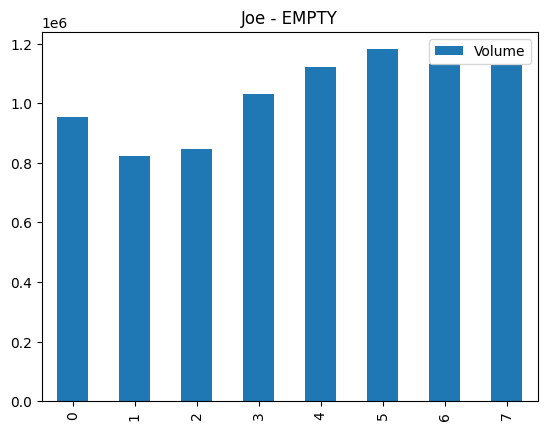

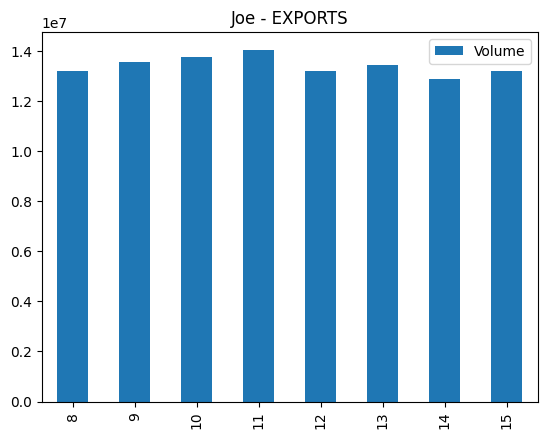

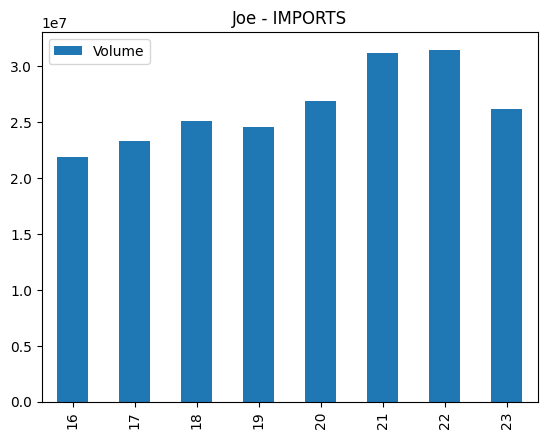

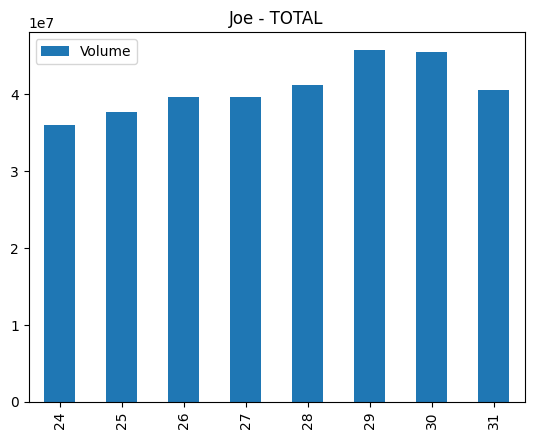

In [148]:
for col in a['Trade Type'].unique():
    print(col)
    a.loc[a['Trade Type'] == col].plot(kind='bar')
    plt.title(f"Joe - {col}")


In [134]:
a.index

MultiIndex([(  'EMPTY', '2016'),
            (  'EMPTY', '2017'),
            (  'EMPTY', '2018'),
            (  'EMPTY', '2019'),
            (  'EMPTY', '2020'),
            (  'EMPTY', '2021'),
            (  'EMPTY', '2022'),
            (  'EMPTY', '2023'),
            ('EXPORTS', '2016'),
            ('EXPORTS', '2017'),
            ('EXPORTS', '2018'),
            ('EXPORTS', '2019'),
            ('EXPORTS', '2020'),
            ('EXPORTS', '2021'),
            ('EXPORTS', '2022'),
            ('EXPORTS', '2023'),
            ('IMPORTS', '2016'),
            ('IMPORTS', '2017'),
            ('IMPORTS', '2018'),
            ('IMPORTS', '2019'),
            ('IMPORTS', '2020'),
            ('IMPORTS', '2021'),
            ('IMPORTS', '2022'),
            ('IMPORTS', '2023'),
            (  'TOTAL', '2016'),
            (  'TOTAL', '2017'),
            (  'TOTAL', '2018'),
            (  'TOTAL', '2019'),
            (  'TOTAL', '2020'),
            (  'TOTAL', '2021'),
          

In [125]:
container_update[['IMPORTS','EXPORTS']].sum()


IMPORTS    30185032.54
EXPORTS    10940679.81
dtype: float64

In [181]:
container_update_all.columns

Index(['PORT NAME', 'STATE', 'DOMESTIC InBound Loaded',
       'DOMESTIC InBound Empty', 'DOMESTIC OutBound Loaded',
       'DOMESTIC OutBound Empty', 'DOMESTIC Total Domestic',
       'FOREIGN InBound Loaded', 'FOREIGN OutBound Loaded',
       'FOREIGN Total Foreign Loaded', 'Grand Total Loaded', 'IMPORTS',
       'EXPORTS', 'EMPTY', 'TOTAL'],
      dtype='object')

In [185]:
print(container_update_all[['DOMESTIC InBound Loaded',
       'DOMESTIC InBound Empty', 'DOMESTIC OutBound Loaded',
       'DOMESTIC OutBound Empty', 'DOMESTIC Total Domestic',
       'FOREIGN InBound Loaded', 'FOREIGN OutBound Loaded',
       'FOREIGN Total Foreign Loaded', 'Grand Total Loaded', 'IMPORTS',
       'EXPORTS', 'EMPTY', 'TOTAL']].sum())

DOMESTIC InBound Loaded          2275025.15
DOMESTIC InBound Empty            773578.10
DOMESTIC OutBound Loaded         2345714.45
DOMESTIC OutBound Empty           752357.85
DOMESTIC Total Domestic          6146675.55
FOREIGN InBound Loaded          30185032.54
FOREIGN OutBound Loaded         10940679.81
FOREIGN Total Foreign Loaded    41125712.35
Grand Total Loaded              45746451.95
IMPORTS                         30185032.54
EXPORTS                         10940679.81
EMPTY                            1525935.95
TOTAL                           41125712.35
dtype: float64


## Check % Change

In [6]:
import pandas as pd
df = pd.read_csv("Port_Data_20260318.csv")
df['Volume'] = df['Volume'].str.replace(",","").astype(float) 
df['Percent Change'] = df['Percent Change'].str.replace(",","").astype(float) 

In [10]:
for  port in df['Port_Name'].unique():
     tmp = df[(df['Port_Name'] == port) & (df['Cargo Type'] == 'DRY BULK')].copy()
     for tt in tmp['Trade Type'].unique():
          tmp2 = tmp[tmp['Trade Type'] == tt]
          for yr in tmp2['Reporting Year'].sort_values().unique():
          
               if yr > tmp2['Reporting Year'].min():
                    val = tmp2[tmp2['Reporting Year'] == yr]['Volume'].values[0]
                    pp = tmp2[tmp2['Reporting Year'] == yr]['Percent Change'].values[0]
                    pp = round(pp,1)
                    valm2 = tmp2[tmp2['Reporting Year'] == yr-1]['Volume']
                    if not valm2.empty:
                        valm2 = valm2.values[0]
                    else:
                        valm2 = 0
                    ppnew = round((val-valm2)/valm2*100,1) if valm2 != 0 else 0
                    
                    diff = abs(pp-ppnew)
                    if diff > .1:
                         print(port,yr,pp,ppnew,val,valm2)
                    if abs(pp) > 200:
                         print("ROH ROH ",tt,port,yr,pp,ppnew,val,valm2)

ROH ROH  EXPORTS Cleveland-Cuyahoga Port, OH 2019 202.8 202.8 65036.0 21475.0
ROH ROH  EXPORTS Cleveland-Cuyahoga Port, OH 2020 557.3 557.3 427465.0 65036.0
ROH ROH  DOMESTIC Tacoma, WA 2019 470.1 470.1 1717656.0 301312.0
ROH ROH  DOMESTIC Tacoma, WA 2023 415.1 415.1 800169.0 155333.0
ROH ROH  FOREIGN Honolulu, O'ahu, HI 2018 7588.4 7588.4 77653.0 1010.0
ROH ROH  FOREIGN Honolulu, O'ahu, HI 2023 183619.0 183619.0 38581.0 21.0
ROH ROH  IMPORTS Honolulu, O'ahu, HI 2018 310512.0 310512.0 77653.0 25.0
ROH ROH  IMPORTS Honolulu, O'ahu, HI 2023 183619.0 183619.0 38581.0 21.0
ROH ROH  DOMESTIC Los Angeles, CA Port of 2018 395.7 395.7 365356.0 73700.0
ROH ROH  FOREIGN Northern Indiana, IN 2020 944.0 944.0 478700.0 45853.0
ROH ROH  IMPORTS Northern Indiana, IN 2020 850.8 850.8 435972.0 45853.0
ROH ROH  IMPORTS Oakland, CA Port of 2020 1120.7 1120.7 1062.0 87.0
ROH ROH  IMPORTS Oakland, CA Port of 2021 355.1 355.1 4833.0 1062.0
ROH ROH  IMPORTS Oakland, CA Port of 2023 2873.5 2873.5 100832.0 339

In [46]:
df.loc[(df['Port_Name'] == 'Alaska, AK Port of') & (df['Cargo Type'] == 'DRY BULK')]

,Cargo Type,Port ID,Port_Name,Region,Reporting Year,State,Trade Type,Units,Port Ranking,Percent Change,Volume
4,DRY BULK,"4,820","Alaska, AK Port of",Pacific Coast,2016,Alaska,DOMESTIC,Short Tons,161.0,-10.155395,96901.0
5,DRY BULK,"4,820","Alaska, AK Port of",Pacific Coast,2016,Alaska,EXPORTS,Short Tons,161.0,0.000000,0.0
6,DRY BULK,"4,820","Alaska, AK Port of",Pacific Coast,2016,Alaska,FOREIGN,Short Tons,161.0,-22.434419,128831.0
7,DRY BULK,"4,820","Alaska, AK Port of",Pacific Coast,2016,Alaska,IMPORTS,Short Tons,161.0,-22.434419,128831.0
8,DRY BULK,"4,820","Alaska, AK Port of",Pacific Coast,2016,Alaska,TOTAL,Short Tons,161.0,-17.600120,225732.0
18,DRY BULK,"4,820","Alaska, AK Port of",Pacific Coast,2017,Alaska,DOMESTIC,Short Tons,172.0,-3.968999,93055.0
19,DRY BULK,"4,820","Alaska, AK Port of",Pacific Coast,2017,Alaska,EXPORTS,Short Tons,172.0,0.000000,0.0
20,DRY BULK,"4,820","Alaska, AK Port of",Pacific Coast,2017,Alaska,FOREIGN,Short Tons,172.0,-40.705265,76390.0
21,DRY BULK,"4,820","Alaska, AK Port of",Pacific Coast,2017,Alaska,IMPORTS,Short Tons,172.0,-40.705265,76390.0
22,DRY BULK,"4,820","Alaska, AK Port of",Pacific Coast,2017,Alaska,TOTAL,Short Tons,172.0,-24.935322,169445.0


In [24]:
df.head()

,Cargo Type,Port ID,Port_Name,Region,Reporting Year,State,Trade Type,Units,Port Ranking,Percent Change,Volume
0,CONTAINER,"4,820","Alaska, AK Port of",Pacific Coast,2016,Alaska,EMPTY,Container TEUs,18.0,42.91847184,58059.20
1,CONTAINER,"4,820","Alaska, AK Port of",Pacific Coast,2016,Alaska,EXPORTS,Container TEUs,18.0,-5.893463975,71169.95
2,CONTAINER,"4,820","Alaska, AK Port of",Pacific Coast,2016,Alaska,IMPORTS,Container TEUs,18.0,-16.02295603,205662.30
3,CONTAINER,"4,820","Alaska, AK Port of",Pacific Coast,2016,Alaska,TOTAL,Container TEUs,18.0,-7.271842483,334891.45
4,DRY BULK,"4,820","Alaska, AK Port of",Pacific Coast,2016,Alaska,DOMESTIC,Short Tons,161.0,-10.15539526,96901.00


In [25]:
df.isna().sum()

Cargo Type           0
Port ID              0
Port_Name            0
Region              93
Reporting Year       0
State                0
Trade Type           0
Units                0
Port Ranking      3193
Percent Change     115
Volume             145
dtype: int64

In [27]:
df[df['Percent Change'].isna()]

,Cargo Type,Port ID,Port_Name,Region,Reporting Year,State,Trade Type,Units,Port Ranking,Percent Change,Volume
5515,DRY BULK,"2,306",Mid-America Port Commission,Gulf Coast & Mississippi River,2022,"Illinois, Iowa, and Missouri",FOREIGN,Short Tons,15.0,NaN,0.0
5516,DRY BULK,"2,306",Mid-America Port Commission,Gulf Coast & Mississippi River,2022,"Illinois, Iowa, and Missouri",IMPORTS,Short Tons,15.0,NaN,0.0
5517,DRY BULK,"2,306",Mid-America Port Commission,Gulf Coast & Mississippi River,2022,"Illinois, Iowa, and Missouri",EXPORTS,Short Tons,15.0,NaN,0.0
5525,DRY BULK,"2,351","New Bourbon Port, MO",Gulf Coast & Mississippi River,2022,Missouri,FOREIGN,Short Tons,18.0,NaN,0.0
5526,DRY BULK,"2,351","New Bourbon Port, MO",Gulf Coast & Mississippi River,2022,Missouri,IMPORTS,Short Tons,18.0,NaN,0.0
...,...,...,...,...,...,...,...,...,...,...,...
7776,TOP 5 COMMODITIES,"3,926","Two Harbors, MN",Great Lakes,2023,Minnesota,TOTAL,Short Tons,NaN,NaN,14617891.0
7782,TOP 5 COMMODITIES,"4,816","Valdez, AK",Pacific Coast,2023,Alaska,TOTAL,Short Tons,NaN,NaN,25434106.0
7788,TOP 5 COMMODITIES,"5,700","Virginia, VA, Port of",Atlantic Coast,2023,Virginia,TOTAL,Short Tons,NaN,NaN,68766562.0
7794,TOP 5 COMMODITIES,555,"Wilmington, DE",Atlantic Coast,2023,Delaware,TOTAL,Short Tons,NaN,NaN,7445983.0


In [28]:
df.dtypes

Cargo Type         object
Port ID            object
Port_Name          object
Region             object
Reporting Year      int64
State              object
Trade Type         object
Units              object
Port Ranking      float64
Percent Change     object
Volume            float64
dtype: object

In [32]:
df['Percent Change'].value_counts().sort_index(ascending=False)

Percent Change
99.555701073    1
99.039832978    1
98.296700791    1
976.3           1
97.64243615     1
               ..
-0.053724149    1
-0.043322782    1
-0.033309995    1
-0.021980623    1
-0.012637639    1
Name: count, Length: 5151, dtype: int64

In [34]:
df[df['Port Ranking'].isna()]

,Cargo Type,Port ID,Port_Name,Region,Reporting Year,State,Trade Type,Units,Port Ranking,Percent Change,Volume
79,TOP 5 COMMODITIES,"4,820","Alaska, AK Port of",Pacific Coast,2021,Alaska,Cement & Concrete,Short Tons,NaN,-30.501027567,88263.0
80,TOP 5 COMMODITIES,"4,820","Alaska, AK Port of",Pacific Coast,2021,Alaska,Distillate Fuel Oil,Short Tons,NaN,180.655466162,118605.0
81,TOP 5 COMMODITIES,"4,820","Alaska, AK Port of",Pacific Coast,2021,Alaska,Food Products NEC,Short Tons,NaN,11.430780475,184477.0
82,TOP 5 COMMODITIES,"4,820","Alaska, AK Port of",Pacific Coast,2021,Alaska,Kerosene,Short Tons,NaN,60.870990392,1727526.0
83,TOP 5 COMMODITIES,"4,820","Alaska, AK Port of",Pacific Coast,2021,Alaska,Manufac. Prod. NEC,Short Tons,NaN,5.458289676,727697.0
...,...,...,...,...,...,...,...,...,...,...,...
8062,TOP 5 FOOD/FARM COMMODITIES,766,"Wilmington, NC",Atlantic Coast,2023,North Carolina,Vegetables & Prod.,Short Tons,NaN,-4.9,81206.0
8063,TOP 5 FOOD/FARM COMMODITIES,766,"Wilmington, NC",Atlantic Coast,2023,North Carolina,Soybeans,Short Tons,NaN,-42.2,70969.0
8064,TOP 5 FOOD/FARM COMMODITIES,766,"Wilmington, NC",Atlantic Coast,2023,North Carolina,"Animal Feed, Prep.",Short Tons,NaN,-28,43434.0
8065,TOP 5 FOOD/FARM COMMODITIES,766,"Wilmington, NC",Atlantic Coast,2023,North Carolina,Bananas & Plantains,Short Tons,NaN,0,24185.0


In [35]:
df.dtypes

Cargo Type         object
Port ID            object
Port_Name          object
Region             object
Reporting Year      int64
State              object
Trade Type         object
Units              object
Port Ranking      float64
Percent Change     object
Volume            float64
dtype: object

In [36]:
df.dropna(subset=['Percent Change'], inplace=True)

In [37]:
df['Percent Change'] = df['Percent Change'].str.replace(",","").astype(float)

In [38]:
df.dtypes

Cargo Type         object
Port ID            object
Port_Name          object
Region             object
Reporting Year      int64
State              object
Trade Type         object
Units              object
Port Ranking      float64
Percent Change    float64
Volume            float64
dtype: object

In [ ]:
df.sort_values['Percent Change'].max()

879580.65